In [1]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import os
from dotenv import load_dotenv
import requests
import sqlite3
from pathlib import Path
import logging

load_dotenv()  # carga las variables del archivo .env


True

In [2]:


AEMET_API_KEY = os.getenv("AEMET_API_KEY")

# Fechas de descarga (ajusta según necesites)
FECHA_INICIO = "2023-01-01"
FECHA_FIN   = datetime.now() - timedelta(days=10)

print(f"Descargando datos desde {FECHA_INICIO} hasta {FECHA_FIN.strftime('%Y-%m-%d')}...")
print("API Key cargada:", "✅" if AEMET_API_KEY else "❌ No encontrada")


Descargando datos desde 2023-01-01 hasta 2026-04-30...
API Key cargada: ✅


In [3]:
# ─────────────────────────────────────────────
# CONFIGURACIÓN
# ─────────────────────────────────────────────

DB_PATH    = "ree_generacion.db"
TABLE_NAME = "generacion"

# NOTA: el endpoint estructura-generacion solo soporta time_trunc=day|month|year
# time_trunc=hour devuelve 400 independientemente del rango o timezone
TIME_TRUNC     = "day"
DIAS_POR_TRAMO = 30

SLEEP_ENTRE_REQ = 1.0

REE_HEADERS = {
    "Accept"      : "application/json",
    "Content-Type": "application/json",
    "Host"        : "apidatos.ree.es",
}

REE_URL = "https://apidatos.ree.es/es/datos/generacion/estructura-generacion"

RENOVABLES = {
    "Eólica", "Solar fotovoltaica", "Solar térmica",
    "Hidráulica", "Hidroeólica", "Otras renovables", "Residuos renovables"
}

ayer         = (datetime.now() - timedelta(days=1)).strftime("%Y-%m-%d")
fecha_inicio = "2022-01-01"   # con day podemos ir hasta 2015+

print(f"Granularidad : {TIME_TRUNC} | Días por tramo: {DIAS_POR_TRAMO}")
print(f"Rango        : {fecha_inicio} → {ayer}")


Granularidad : day | Días por tramo: 30
Rango        : 2022-01-01 → 2026-05-09


In [4]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S"
)
log = logging.getLogger(__name__)

In [5]:
# ─────────────────────────────────────────────
# CAPA DE BASE DE DATOS
# ─────────────────────────────────────────────

def _get_conn() -> sqlite3.Connection:
    conn = sqlite3.connect(DB_PATH)
    conn.execute("PRAGMA journal_mode=WAL")   # escrituras más rápidas
    return conn


def _init_db():
    """Crea la tabla si no existe."""
    with _get_conn() as conn:
        conn.execute(f"""
            CREATE TABLE IF NOT EXISTS {TABLE_NAME} (
                datetime    TEXT NOT NULL,
                tecnologia  TEXT NOT NULL,
                tipo        TEXT,
                valor_MWh   REAL,
                porcentaje  REAL,
                PRIMARY KEY (datetime, tecnologia)
            )
        """)
        # Índice para acelerar consultas por fecha
        conn.execute(f"""
            CREATE INDEX IF NOT EXISTS idx_datetime
            ON {TABLE_NAME} (datetime)
        """)
    log.info(f"BD lista: {DB_PATH}")
    
def _fechas_en_bd() -> tuple[str | None, str | None]:
    """Devuelve (fecha_min, fecha_max) de lo que hay en la BD, o (None, None)."""
    with _get_conn() as conn:
        row = conn.execute(
            f"SELECT MIN(datetime), MAX(datetime) FROM {TABLE_NAME}"
        ).fetchone()
    return row if row else (None, None)


def _guardar_df(df: pd.DataFrame):
    """Inserta filas nuevas, ignora duplicados (INSERT OR IGNORE)."""
    if df.empty:
        return
    with _get_conn() as conn:
        df.to_sql("_tmp", conn, if_exists="replace", index=False)
        conn.execute(f"""
            INSERT OR IGNORE INTO {TABLE_NAME}
                (datetime, tecnologia, tipo, valor_MWh, porcentaje)
            SELECT datetime, tecnologia, tipo, valor_MWh, porcentaje
            FROM _tmp
        """)
        conn.execute("DROP TABLE _tmp")
    log.info(f"  ✅ Guardados {len(df)} registros")


def _leer_bd(fecha_inicio: str, fecha_fin: str,
             solo_renovables: bool = True) -> pd.DataFrame:
    """Lee de la BD el rango indicado."""
    query = f"""
        SELECT * FROM {TABLE_NAME}
        WHERE datetime >= ? AND datetime <= ?
        {"AND tecnologia IN (" + ",".join("?"*len(RENOVABLES)) + ")" if solo_renovables else ""}
        ORDER BY datetime
    """
    params = [fecha_inicio, fecha_fin]
    if solo_renovables:
        params += list(RENOVABLES)

    with _get_conn() as conn:
        df = pd.read_sql_query(query, conn, params=params)

    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
    return df


In [6]:
# ─────────────────────────────────────────────
# CAPA DE API
# ─────────────────────────────────────────────

def _consultar_api(fecha_inicio: str, fecha_fin: str) -> pd.DataFrame:
    """
    Hace UNA petición a la API de REE para el rango dado.
    NOTA: estructura-generacion solo soporta time_trunc=day|month|year.
    """
    url = (
        f"{REE_URL}"
        f"?start_date={fecha_inicio}T00:00"
        f"&end_date={fecha_fin}T23:59"
        f"&time_trunc={TIME_TRUNC}"
        f"&geo_trunc=electric_system"
        f"&geo_limit=peninsular"
        f"&geo_ids=8741"
    )

    try:
        r = requests.get(url, headers=REE_HEADERS, timeout=30)
    except requests.exceptions.RequestException as e:
        log.warning(f"  ⚠️  Error de red: {e}")
        return pd.DataFrame()

    if r.status_code != 200:
        log.warning(f"  ⚠️  HTTP {r.status_code} para {fecha_inicio} → {fecha_fin}: {r.text[:120]}")
        return pd.DataFrame()

    tecnologias = r.json().get("included", [])
    registros = []

    for tec in tecnologias:
        nombre = tec.get("attributes", {}).get("title", "")
        tipo   = tec.get("attributes", {}).get("type", "")
        if nombre not in RENOVABLES:
            continue
        for val in tec.get("attributes", {}).get("values", []):
            registros.append({
                "datetime"  : val.get("datetime"),
                "tecnologia": nombre,
                "tipo"      : tipo,
                "valor_MWh" : val.get("value"),
                "porcentaje": val.get("percentage"),
            })

    if not registros:
        log.warning(f"  ⚠️  Sin registros para {fecha_inicio} → {fecha_fin}")
        return pd.DataFrame()

    df = pd.DataFrame(registros)
    df["datetime"] = (
        pd.to_datetime(df["datetime"], utc=True)
          .dt.strftime("%Y-%m-%dT%H:%M:%SZ")
    )
    return df


# ─────────────────────────────────────────────
# FUNCIÓN PRINCIPAL 1: GENERAR HISTÓRICO
# ─────────────────────────────────────────────

def generar_historico(fecha_inicio: str, fecha_fin: str,
                      dias_por_tramo: int = DIAS_POR_TRAMO,
                      forzar: bool = False):
    _init_db()

    inicio = datetime.strptime(fecha_inicio, "%Y-%m-%d")
    fin    = datetime.strptime(fecha_fin,    "%Y-%m-%d")

    tramos = []
    actual = inicio
    while actual <= fin:
        tramo_fin = min(actual + timedelta(days=dias_por_tramo - 1), fin)
        tramos.append((actual.strftime("%Y-%m-%d"), tramo_fin.strftime("%Y-%m-%d")))
        actual = tramo_fin + timedelta(days=1)

    total = len(tramos)
    log.info(f"📅 Histórico {fecha_inicio} → {fecha_fin} | {total} tramos de {dias_por_tramo} días")

    fecha_min_bd, fecha_max_bd = _fechas_en_bd()
    descargados = 0
    omitidos    = 0

    for i, (t_ini, t_fin) in enumerate(tramos, 1):
        if not forzar and fecha_max_bd:
            t_ini_dt = datetime.strptime(t_ini, "%Y-%m-%d")
            t_max_bd = datetime.strptime(fecha_max_bd[:10], "%Y-%m-%d")
            if t_ini_dt <= t_max_bd:
                omitidos += 1
                continue

        log.info(f"  [{i:03d}/{total}] Descargando {t_ini} → {t_fin}...")
        df = _consultar_api(t_ini, t_fin)

        if not df.empty:
            _guardar_df(df)
            descargados += 1
        else:
            log.warning(f"  [{i:03d}/{total}] Sin datos — tramo omitido")
            

        time.sleep(SLEEP_ENTRE_REQ)

    log.info(f"\n✅ Histórico completado | descargados: {descargados} | omitidos (ya en BD): {omitidos}")
    _mostrar_resumen_bd()


# ─────────────────────────────────────────────
# FUNCIÓN PRINCIPAL 2: OBTENER DATOS (con caché)
# ─────────────────────────────────────────────

def obtener_datos(fecha_inicio: str, fecha_fin: str,
                  solo_renovables: bool = True) -> pd.DataFrame:
    _init_db()

    fecha_min_bd, fecha_max_bd = _fechas_en_bd()
    fin_dt = datetime.strptime(fecha_fin, "%Y-%m-%d")

    if fecha_max_bd:
        ultimo_en_bd = datetime.strptime(fecha_max_bd[:10], "%Y-%m-%d")
        if ultimo_en_bd < fin_dt:
            nuevo_inicio = (ultimo_en_bd + timedelta(days=1)).strftime("%Y-%m-%d")
            log.info(f"🔄 Actualizando BD: {nuevo_inicio} → {fecha_fin}")
            _descargar_rango_incremental(nuevo_inicio, fecha_fin)
        else:
            log.info("✅ BD al día, sin necesidad de consultar la API")
    else:
        log.info(f"📭 BD vacía. Descargando {fecha_inicio} → {fecha_fin}")
        _descargar_rango_incremental(fecha_inicio, fecha_fin)

    df = _leer_bd(fecha_inicio, fecha_fin, solo_renovables=solo_renovables)
    log.info(f"📊 Retornando {len(df)} registros desde la BD")
    return df


def _descargar_rango_incremental(fecha_inicio: str, fecha_fin: str):
    inicio = datetime.strptime(fecha_inicio, "%Y-%m-%d")
    fin    = datetime.strptime(fecha_fin,    "%Y-%m-%d")
    actual = inicio

    while actual <= fin:
        tramo_fin = min(actual + timedelta(days=DIAS_POR_TRAMO - 1), fin)
        t_ini_str = actual.strftime("%Y-%m-%d")
        t_fin_str = tramo_fin.strftime("%Y-%m-%d")

        log.info(f"  → Descargando {t_ini_str} → {t_fin_str}")
        df = _consultar_api(t_ini_str, t_fin_str)

        if not df.empty:
            _guardar_df(df)

        actual = tramo_fin + timedelta(days=1)
        time.sleep(SLEEP_ENTRE_REQ)


# ─────────────────────────────────────────────
# UTILIDADES
# ─────────────────────────────────────────────

def _mostrar_resumen_bd():
    fecha_min, fecha_max = _fechas_en_bd()
    with _get_conn() as conn:
        n_filas = conn.execute(f"SELECT COUNT(*) FROM {TABLE_NAME}").fetchone()[0]
        tecns   = conn.execute(
            f"SELECT tecnologia, COUNT(*) as n FROM {TABLE_NAME} GROUP BY tecnologia"
        ).fetchall()

    log.info(f"\n📦 Estado de la BD ({DB_PATH}):")
    log.info(f"   Rango   : {fecha_min} → {fecha_max}")
    log.info(f"   Total   : {n_filas:,} filas")
    log.info(f"   Por tecnología:")
    for tec, n in tecns:
        log.info(f"     {tec:<30} {n:>8,} filas")


def exportar_pivot(df: pd.DataFrame) -> pd.DataFrame:
    df_pivot = df.pivot_table(
        index="datetime",
        columns="tecnologia",
        values="valor_MWh",
        aggfunc="sum"
    ).reset_index()

    df_pivot.columns.name = None

    df_pivot["dia_semana"]    = df_pivot["datetime"].dt.dayofweek
    df_pivot["mes"]           = df_pivot["datetime"].dt.month
    df_pivot["es_fin_semana"] = df_pivot["dia_semana"].isin([5, 6]).astype(int)
    df_pivot["trimestre"]     = df_pivot["datetime"].dt.quarter

    return df_pivot


In [7]:
# ── Paso 1: Generar histórico (últimos 2 años con granularidad horaria)
generar_historico(fecha_inicio, ayer)

# ── Paso 2: Obtener datos (con caché, solo descarga lo que falta)
df = obtener_datos(fecha_inicio, ayer)

print(f"\nDataFrame: {df.shape}")
print(df.head())

# ── Paso 3: Convertir a formato wide para ML
df_ml = exportar_pivot(df)
print(f"\nDataFrame para ML: {df_ml.shape}")
print(df_ml.columns.tolist())

# ── Opcional: exportar a CSV
df_ml.to_csv("dataset_ree_para_ml.csv", index=False)
print("\n💾 Guardado: dataset_ree_para_ml.csv")


23:47:23  INFO  BD lista: ree_generacion.db
23:47:23  INFO  📅 Histórico 2022-01-01 → 2026-05-09 | 53 tramos de 30 días
23:47:23  INFO  
✅ Histórico completado | descargados: 0 | omitidos (ya en BD): 53
23:47:23  INFO  
📦 Estado de la BD (ree_generacion.db):
23:47:23  INFO     Rango   : 2021-12-31T23:00:00Z → 2026-05-08T22:00:00Z
23:47:23  INFO     Total   : 9,540 filas
23:47:23  INFO     Por tecnología:
23:47:23  INFO       Eólica                            1,590 filas
23:47:23  INFO       Hidráulica                        1,590 filas
23:47:23  INFO       Otras renovables                  1,590 filas
23:47:23  INFO       Residuos renovables               1,590 filas
23:47:23  INFO       Solar fotovoltaica                1,590 filas
23:47:23  INFO       Solar térmica                     1,590 filas
23:47:23  INFO  BD lista: ree_generacion.db
23:47:23  INFO  🔄 Actualizando BD: 2026-05-09 → 2026-05-09
23:47:23  INFO    → Descargando 2026-05-09 → 2026-05-09
23:47:24  INFO    ✅ Guardados 6 

23:47:23  INFO  BD lista: ree_generacion.db
23:47:23  INFO  📅 Histórico 2022-01-01 → 2026-05-09 | 53 tramos de 30 días
23:47:23  INFO  
✅ Histórico completado | descargados: 0 | omitidos (ya en BD): 53
23:47:23  INFO  
📦 Estado de la BD (ree_generacion.db):
23:47:23  INFO     Rango   : 2021-12-31T23:00:00Z → 2026-05-08T22:00:00Z
23:47:23  INFO     Total   : 9,540 filas
23:47:23  INFO     Por tecnología:
23:47:23  INFO       Eólica                            1,590 filas
23:47:23  INFO       Hidráulica                        1,590 filas
23:47:23  INFO       Otras renovables                  1,590 filas
23:47:23  INFO       Residuos renovables               1,590 filas
23:47:23  INFO       Solar fotovoltaica                1,590 filas
23:47:23  INFO       Solar térmica                     1,590 filas
23:47:23  INFO  BD lista: ree_generacion.db
23:47:23  INFO  🔄 Actualizando BD: 2026-05-09 → 2026-05-09
23:47:23  INFO    → Descargando 2026-05-09 → 2026-05-09
23:47:24  INFO    ✅ Guardados 6 


DataFrame: (9534, 5)
                   datetime          tecnologia       tipo   valor_MWh  \
0 2022-01-01 23:00:00+00:00          Hidráulica  Renovable   52663.908   
1 2022-01-01 23:00:00+00:00              Eólica  Renovable  103224.219   
2 2022-01-01 23:00:00+00:00  Solar fotovoltaica  Renovable   42032.416   
3 2022-01-01 23:00:00+00:00       Solar térmica  Renovable    4509.884   
4 2022-01-01 23:00:00+00:00    Otras renovables  Renovable   14173.180   

   porcentaje  
0    0.097975  
1    0.192036  
2    0.078196  
3    0.008390  
4    0.026367  

DataFrame para ML: (1589, 11)
['datetime', 'Eólica', 'Hidráulica', 'Otras renovables', 'Residuos renovables', 'Solar fotovoltaica', 'Solar térmica', 'dia_semana', 'mes', 'es_fin_semana', 'trimestre']

💾 Guardado: dataset_ree_para_ml.csv


In [8]:
df_ree = pd.read_csv("dataset_ree_para_ml.csv")
df_ree

,datetime,Eólica,Hidráulica,Otras renovables,Residuos renovables,Solar fotovoltaica,Solar térmica,dia_semana,mes,es_fin_semana,trimestre
0,2022-01-01 23:00:00+00:00,103224.219,52663.908,14173.180,2387.7820,42032.416,4509.884,5,1,1,1
1,2022-01-02 23:00:00+00:00,151458.364,53068.508,14249.328,2388.4350,46275.789,6250.758,6,1,1,1
2,2022-01-03 23:00:00+00:00,302569.215,51497.125,14951.210,2361.4625,26961.168,1141.307,0,1,0,1
3,2022-01-04 23:00:00+00:00,288109.621,57195.362,14758.413,2387.6545,33969.307,1970.000,1,1,0,1
4,2022-01-05 23:00:00+00:00,196473.458,60819.354,14508.809,2363.1080,51808.514,6858.916,2,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1584,2026-05-04 22:00:00+00:00,83562.100,108686.900,9932.200,1388.9500,199259.458,19236.942,0,5,0,2
1585,2026-05-05 22:00:00+00:00,58772.300,111138.600,9759.800,1204.3000,218149.761,18861.239,1,5,0,2
1586,2026-05-06 22:00:00+00:00,78262.300,123799.200,10345.000,1231.4000,199466.764,16117.236,2,5,0,2
1587,2026-05-07 22:00:00+00:00,102631.200,107705.800,11078.700,1224.2000,179791.739,12943.061,3,5,0,2


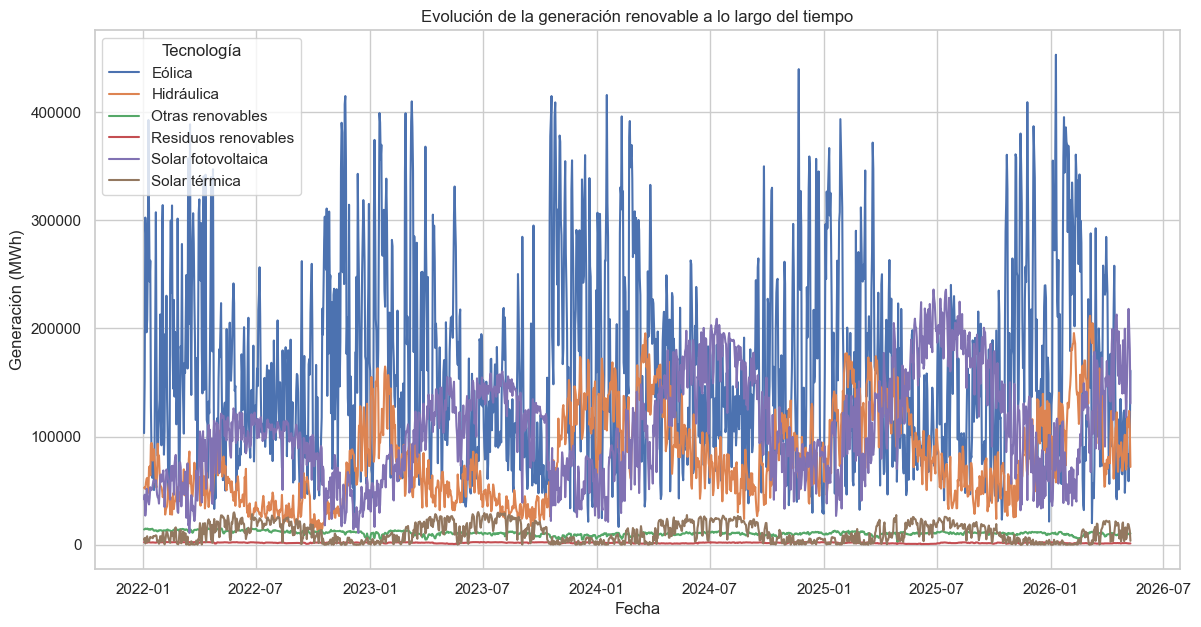

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df_ree['datetime'] = pd.to_datetime(df_ree['datetime'])

# El CSV está en formato wide → convertir a long para poder graficar por tecnología
tecnologias = [c for c in df_ree.columns if c not in ('datetime', 'hora', 'dia_semana', 'mes', 'es_fin_semana', 'trimestre')]

df_long = df_ree.melt(
    id_vars='datetime',
    value_vars=tecnologias,
    var_name='tecnologia',
    value_name='valor_MWh'
)

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_long, x='datetime', y='valor_MWh', hue='tecnologia')
plt.title('Evolución de la generación renovable a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Generación (MWh)')
plt.legend(title='Tecnología')
plt.show()


                   datetime      Eólica  Solar fotovoltaica  Hidráulica
0 2022-01-01 23:00:00+00:00  103224.219           42032.416   52663.908
1 2022-01-02 23:00:00+00:00  151458.364           46275.789   53068.508
2 2022-01-03 23:00:00+00:00  302569.215           26961.168   51497.125
3 2022-01-04 23:00:00+00:00  288109.621           33969.307   57195.362
4 2022-01-05 23:00:00+00:00  196473.458           51808.514   60819.354


C:\Users\jlalo\AppData\Local\Temp\ipykernel_20360\2933305573.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ree_filtrado['datetime'] = pd.to_datetime(df_ree_filtrado['datetime'])


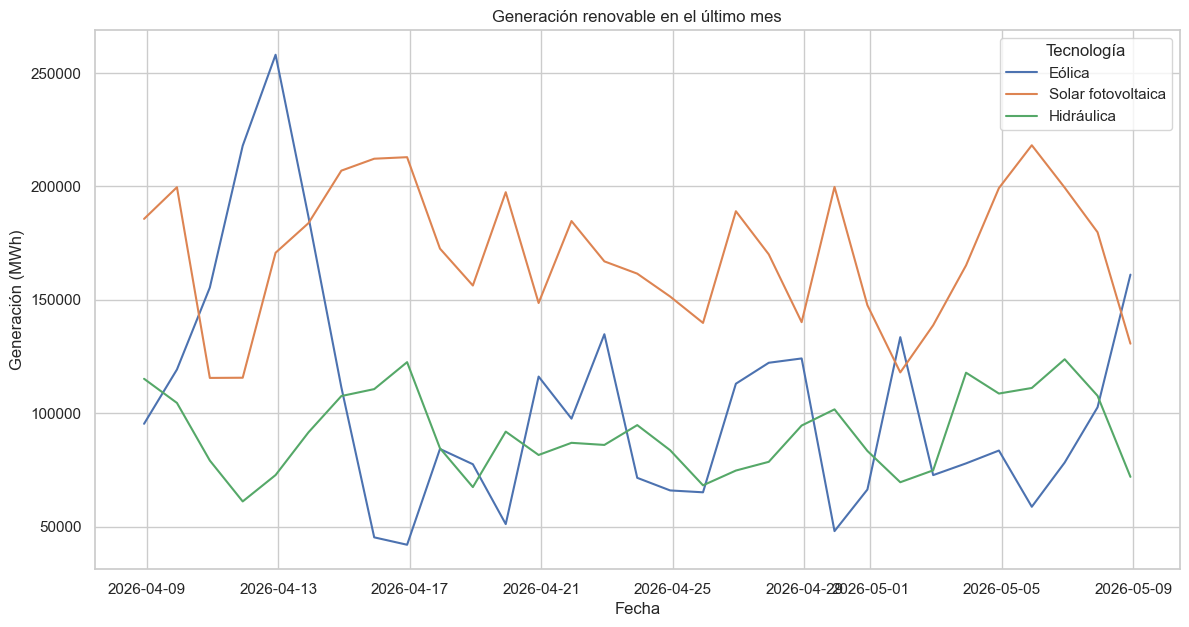

In [10]:
# vamos a quedarnos con los datos de las energias Eolica, Solar fotovoltaica e hidraulica
df_ree_filtrado = df_ree[['datetime', 'Eólica', 'Solar fotovoltaica', 'Hidráulica']]
print(df_ree_filtrado.head())
# ahora vamos a impromir la gráfica del último mes
df_ree_filtrado['datetime'] = pd.to_datetime(df_ree_filtrado['datetime'])
ayer = df_ree_filtrado['datetime'].max()
hace_un_mes = ayer - pd.DateOffset(months=1)
df_ultimo_mes = df_ree_filtrado[df_ree_filtrado['datetime'] >= hace_un_mes] 
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_ultimo_mes, x='datetime', y='Eólica', label='Eólica')
sns.lineplot(data=df_ultimo_mes, x='datetime', y='Solar fotovoltaica', label='Solar fotovoltaica')
sns.lineplot(data=df_ultimo_mes, x='datetime', y='Hidráulica', label='Hidráulica')
plt.title('Generación renovable en el último mes')
plt.xlabel('Fecha')
plt.ylabel('Generación (MWh)')
plt.legend(title='Tecnología')
plt.show()


In [11]:
# coordenaddas de parques eólicos en España
parques_eolicos = [
    {"nombre": "Parque Eólico El Andévalo", "latitud": 37.26418296737997, "longitud": -6.944856396315273},
    {"nombre": "Parque Eólico Maranchón", "latitud": 41.06356588209968, "longitud": -2.206160824662825},
    {"nombre": "Parque Eólico de Borja", "latitud": 41.877046928697204, "longitud": -1.5630303402886618},
    {"nombre": "Parque Eólico La Muela", "latitud": 41.5924449830392, "longitud": -1.1575020732335635},
    {"nombre": "Parque Eólico Gecama", "latitud": 39.40848408319995, "longitud": -2.2192737751771614},  
    {"nombre": "Parque Eólico De Tarifa", "latitud": 36.037373555997895, "longitud": -5.570950423574283},
    {"nombre": "Parque Eólico De BRIVIESCA", "latitud": 42.52921710077489, "longitud": -3.408352539310985},
]
estaciones_meteorologicas_eolicas = [
    {"nombre": "ALBACETE BASE AÉREA", "id": "8175", "latitud": "385715N", "longitud": "015123W"},
    {"nombre": "EL CERRO DE ANDÉVALO", "id": "4584X", "latitud": "374354N", "longitud": "065632W"},
    {"nombre": "MOLINA DE ARAGÓN", "id": "3013","latitud": "405030N", "longitud": "015244W"},
    {"nombre": "TARIFA", "id": "6001", "latitud": "360050N", "longitud": "053556W"},
    {"nombre": "BRIVIESCA", "id": "9031C","latitud": "423334N", "longitud": "031832W"},
    {"nombre": "TARAZONA", "id": "9299X", "latitud": "415454N", "longitud": "014324W"},
]

parques_fotovoltaicos = [
    {"nombre": "Planta fotovoltaico Francisco Pizarro (Badajoz)", "latitud": 39.57548807687309, "longitud": -5.703950830737011},
    {"nombre": "Fotovoltaica Núñez de Balboa (Badajoz)", "latitud": 38.45850924643206, "longitud": -6.2250765591031385},
    {"nombre": "Planta fotovoltaico Mula (Murcia)", "latitud": 37.956708293592285, "longitud": -1.405689511723174},
    {"nombre": "Complejosolar  Don Rodrigo (Sevilla)", "latitud": 37.22236102311706, "longitud": -5.868508779143092},
    {"nombre": "Chiprana-Samper (Zaragoza)", "latitud": 41.26513813979229, "longitud": -0.17859978315982314},
]
estaciones_meteorologicas_fotovoltaicas = [
    {"nombre": "TRUJILLO", "id": "3463Y", "latitud": "392751N", "longitud": "055227W"},
    {"nombre": "ZAFRA", "id": "4427X", "latitud": "382533N", "longitud": "062612W"},
    {"nombre": "CARTAGENA", "id": "7012C", "latitud": "373604N", "longitud": "005916W"},
    {"nombre": "SEVILLA AEROPUERTO", "id": "5783", "latitud": "372500N", "longitud": "055245W"},
    {"nombre": "CASPE, PLANA DEL PILÓN", "id": "9574B", "latitud": "411433N", "longitud": "000407W"}
]

parques_hidraulicos = [
    {"nombre": "Central Hidroeléctrica La Muela", "latitud": 39.2451123345447, "longitud": -0.9309305265255817},
    {"nombre": "Presa de Aldeadávila (Salamanca)", "latitud": 41.21154029377498, "longitud": -6.686200802113904},
    {"nombre": "central hidrologica  de Brozas (Cáceres)", "latitud": 39.73043252018211, "longitud": -6.884840283864805}
]
estaciones_meteorologicas_hidraulicas = [
    {"nombre": "JALANCE", "id": "8193E", "latitud": "391230N", "longitud": "010540W"},
    {"nombre": "VITIGUDINO", "id": "2916A", "latitud": "410041N", "longitud": "062616W"},
    {"nombre": "BROZAS", "id": "3565X", "latitud": "393705N", "longitud": "064442W"}
]

In [12]:
# ── Paso 1: conectar con AEMET y ver la respuesta ─────────────────────────────
# Pedimos datos de Madrid (código 3195) para un único mes de prueba

FECHA_INI = "2022-01-01T00:00:00UTC"
# la fecha fin es la fecha de hoy
FECHA_FIN = (datetime.now() - timedelta(days=3)).strftime("%Y-%m-%dT%H:%M:%SUTC")

provincias_eolicas = {
    "Parque Eólico Gecama (Cuenca)": "8175",
    "Complejo El Andévalo (Huelva)": "4584X",
    "Parque Eólico Maranchón (Guadalajara)": "3013",
    "Zona de Tarifa (Cádiz)": "6001",
    "Poza BRIVIESCA (Burgos)": "9031C",
    "Tarazona (Zaragoza)": "9299X",
}

provincias_fotovoltaicas = {
    "Planta Francisco Pizarro (Badajoz)": "3463Y",
    "Planta Núñez de Balboa (Badajoz)": "4427X",
    "Planta Solar de Mula (Murcia)": "7012C",
    "Complejo Don Rodrigo (Sevilla)": "5783",
    "Chiprana-Samper (Zaragoza)": "9574B",
}

provincias_hidraulicas = {
    "La Muela (Valencia)": "8193E",
    "Aldeadávila (Salamanca)": "2916A",
    "Brozas (Cáceres)": "3565X",
}



In [13]:
# ─────────────────────────────────────────────
# AEMET: Tabla, comprobación y guardado en BD
# ─────────────────────────────────────────────

AEMET_TABLE  = "aemet_diario"
AEMET_CAMPOS = ["fecha", "indicativo", "nombre", "provincia",
                "tmed", "tmin", "tmax", "velmedia", "racha", "prec", "sol"]


def _init_aemet_db():
    """Crea la tabla aemet_diario si no existe."""
    with _get_conn() as conn:
        conn.execute(f"""
            CREATE TABLE IF NOT EXISTS {AEMET_TABLE} (
                fecha       TEXT NOT NULL,
                indicativo  TEXT NOT NULL,
                nombre      TEXT,
                provincia   TEXT,
                tmed        REAL,
                tmin        REAL,
                tmax        REAL,
                velmedia    REAL,
                racha       REAL,
                prec        REAL,
                sol         REAL,
                PRIMARY KEY (fecha, indicativo)
            )
        """)
        conn.execute(f"CREATE INDEX IF NOT EXISTS idx_aemet_fecha ON {AEMET_TABLE} (fecha)")
        conn.execute(f"CREATE INDEX IF NOT EXISTS idx_aemet_ind   ON {AEMET_TABLE} (indicativo)")
    print(f"✅ Tabla '{AEMET_TABLE}' lista en {DB_PATH}")


def _fechas_en_bd_aemet(indicativo: str, fecha_ini: str, fecha_fin: str) -> set:
    """Devuelve el set de fechas ya registradas para la estación en el rango dado."""
    with _get_conn() as conn:
        rows = conn.execute(
            f"SELECT fecha FROM {AEMET_TABLE} "
            f"WHERE indicativo = ? AND fecha >= ? AND fecha <= ?",
            (indicativo, fecha_ini, fecha_fin)
        ).fetchall()
    return {row[0] for row in rows}


def _parse_float(val):
    """Convierte valores AEMET (coma decimal, 'Ip', vacíos) a float o None."""
    if val is None or str(val).strip() in ("", "Ip", "Acum"):
        return None
    try:
        return float(str(val).replace(",", "."))
    except ValueError:
        return None


def _guardar_aemet(registros: list) -> int:
    """Inserta registros en aemet_diario ignorando duplicados. Devuelve nº guardados."""
    if not registros:
        return 0
    df_tmp = pd.DataFrame(registros, columns=AEMET_CAMPOS)
    with _get_conn() as conn:
        df_tmp.to_sql("_tmp_aemet", conn, if_exists="replace", index=False)
        conn.execute(f"""
            INSERT OR IGNORE INTO {AEMET_TABLE}
                (fecha, indicativo, nombre, provincia,
                 tmed, tmin, tmax, velmedia, racha, prec, sol)
            SELECT fecha, indicativo, nombre, provincia,
                   tmed, tmin, tmax, velmedia, racha, prec, sol
            FROM _tmp_aemet
        """)
        conn.execute("DROP TABLE _tmp_aemet")
    return len(registros)


def _consultar_aemet_api(indicativo: str, fecha_ini: str, fecha_fin: str):
    """
    Consulta AEMET (doble petición: meta-URL -> datos reales).
    Devuelve (registros, error_info).
    - registros: lista de filas para insertar
    - error_info: None si todo ok, o dict con causa/url/detalle para reintentos
    """
    url = (
        f"https://opendata.aemet.es/opendata/api/valores/climatologicos/diarios"
        f"/datos/fechaini/{fecha_ini}T00:00:00UTC/fechafin/{fecha_fin}T23:59:59UTC"
        f"/estacion/{indicativo}?api_key={AEMET_API_KEY}"
    )
    url_publica = url.split("?api_key=")[0]
    headers = {"Accept": "application/json"}

    # 1) Petición para obtener la URL de datos
    try:
        r1 = requests.get(url, headers=headers, timeout=30)
    except requests.exceptions.RequestException as e:
        error = {
            "causa": "red_primera_peticion",
            "url": url_publica,
            "detalle": str(e),
            "estacion": indicativo,
            "fecha_ini": fecha_ini,
            "fecha_fin": fecha_fin,
        }
        print("      ❌ Error de red (1ª petición)")
        print(f"         URL  : {url_publica}")
        print(f"         Error: {e}")
        return [], error

    if r1.status_code != 200:
        try:
            detalle = r1.json().get("descripcion", r1.text[:300])
        except Exception:
            detalle = r1.text[:300]
        error = {
            "causa": f"http_{r1.status_code}_primera_peticion",
            "url": url_publica,
            "detalle": str(detalle),
            "estacion": indicativo,
            "fecha_ini": fecha_ini,
            "fecha_fin": fecha_fin,
        }
        print(f"      ❌ HTTP {r1.status_code} (1ª petición)")
        print(f"         URL  : {url_publica}")
        print(f"         Error: {detalle}")
        return [], error

    r1_json = r1.json()
    datos_url = r1_json.get("datos")
    if not datos_url:
        desc = r1_json.get("descripcion", "sin descripción")
        error = {
            "causa": "sin_url_datos",
            "url": url_publica,
            "detalle": str(desc),
            "estacion": indicativo,
            "fecha_ini": fecha_ini,
            "fecha_fin": fecha_fin,
        }
        print(f"      ⚠️  Sin URL de datos  ({indicativo} | {fecha_ini} → {fecha_fin})")
        print(f"         URL      : {url_publica}")
        print(f"         Respuesta: {desc}")
        return [], error

    # 2) Petición de datos reales
    try:
        r2 = requests.get(datos_url, headers=headers, timeout=30)
    except requests.exceptions.RequestException as e:
        error = {
            "causa": "red_segunda_peticion",
            "url": datos_url,
            "detalle": str(e),
            "estacion": indicativo,
            "fecha_ini": fecha_ini,
            "fecha_fin": fecha_fin,
        }
        print("      ❌ Error de red (2ª petición)")
        print(f"         URL  : {datos_url}")
        print(f"         Error: {e}")
        return [], error

    if r2.status_code != 200:
        try:
            detalle2 = r2.json().get("descripcion", r2.text[:300])
        except Exception:
            detalle2 = r2.text[:300]
        error = {
            "causa": f"http_{r2.status_code}_segunda_peticion",
            "url": datos_url,
            "detalle": str(detalle2),
            "estacion": indicativo,
            "fecha_ini": fecha_ini,
            "fecha_fin": fecha_fin,
        }
        print(f"      ❌ HTTP {r2.status_code} (2ª petición)")
        print(f"         URL  : {datos_url}")
        print(f"         Error: {detalle2}")
        return [], error

    datos = r2.json()
    if not isinstance(datos, list):
        detalle3 = str(datos)[:300]
        error = {
            "causa": "respuesta_no_lista",
            "url": datos_url,
            "detalle": detalle3,
            "estacion": indicativo,
            "fecha_ini": fecha_ini,
            "fecha_fin": fecha_fin,
        }
        print("      ⚠️  Respuesta inesperada (no es lista)")
        print(f"         URL      : {datos_url}")
        print(f"         Respuesta: {detalle3}")
        return [], error

    registros = []
    for d in datos:
        registros.append([
            d.get("fecha"),
            d.get("indicativo"),
            d.get("nombre"),
            d.get("provincia"),
            _parse_float(d.get("tmed")),
            _parse_float(d.get("tmin")),
            _parse_float(d.get("tmax")),
            _parse_float(d.get("velmedia")),
            _parse_float(d.get("racha")),
            _parse_float(d.get("prec")),
            _parse_float(d.get("sol")),
        ])

    return registros, None


In [14]:
# ─────────────────────────────────────────────
# AEMET: Bucle principal de descarga
# ─────────────────────────────────────────────
# Esta función descarga el histórico entre fecha_inicio y fecha_fin,
# divide el rango en tramos de dias_por_tramo para evitar timeouts,
# y guarda las URLs con error agrupadas por causa para reintentos.

def descargar_aemet(fecha_inicio: str, fecha_fin: str, dias_por_tramo: int = 3):
    """
    Descarga datos climáticos de AEMET para todas las estaciones.
    - Divide el rango en tramos de dias_por_tramo días.
    - Omite días ya existentes en BD.
    - Pausa 60 s cada 5 peticiones efectivas.
    - Guarda los registros en ree_generacion.db / aemet_diario.
    - Agrupa errores por causa con sus URLs para reintentar después.
    """
    _init_aemet_db()

    # Unificar diccionarios de estaciones, evitando duplicados por código
    todas = {}
    for d in (provincias_eolicas, provincias_fotovoltaicas, provincias_hidraulicas):
        for nombre, codigo in d.items():
            if codigo not in todas:
                todas[codigo] = nombre

    # Construir tramos
    inicio_dt = datetime.strptime(fecha_inicio, "%Y-%m-%d")
    fin_dt    = datetime.strptime(fecha_fin, "%Y-%m-%d")
    tramos = []
    actual = inicio_dt
    while actual <= fin_dt:
        tramo_fin = min(actual + timedelta(days=dias_por_tramo - 1), fin_dt)
        tramos.append((actual.strftime("%Y-%m-%d"), tramo_fin.strftime("%Y-%m-%d")))
        actual = tramo_fin + timedelta(days=1)

    n_estaciones = len(todas)
    total_peticiones = 0
    total_guardados = 0
    total_omitidos = 0
    total_errores = 0
    errores_por_causa = {}

    print(f"\n{'='*65}")
    print(f"  📡 DESCARGA AEMET  |  {fecha_inicio} → {fecha_fin}")
    print(f"  Estaciones únicas : {n_estaciones}")
    print(f"  Tramos de {dias_por_tramo} días  |  {len(tramos)} tramos por estación")
    print("  Pausa 60 s cada 5 peticiones efectivas")
    print(f"{'='*65}")

    for idx_est, (codigo, nombre_est) in enumerate(todas.items(), 1):
        print(f"\n┌─ [{idx_est:02d}/{n_estaciones}]  {nombre_est}  ({codigo})")
        est_guardados = 0
        est_omitidos = 0
        est_errores = 0

        for t_ini, t_fin in tramos:
            fechas_bd = _fechas_en_bd_aemet(codigo, t_ini, t_fin)

            dias_tramo = []
            d = datetime.strptime(t_ini, "%Y-%m-%d")
            while d <= datetime.strptime(t_fin, "%Y-%m-%d"):
                dias_tramo.append(d.strftime("%Y-%m-%d"))
                d += timedelta(days=1)

            for dia_bd in sorted(fechas_bd.intersection(set(dias_tramo))):
                print(f"│  ⏭️  {dia_bd}  estación {codigo} ya existe en BD")
                est_omitidos += 1

            dias_faltantes = [dia for dia in dias_tramo if dia not in fechas_bd]
            if not dias_faltantes:
                continue

            print(f"│  📥 {t_ini} → {t_fin}  ({len(dias_faltantes)} días nuevos) ...", end=" ", flush=True)
            registros, error_info = _consultar_aemet_api(codigo, t_ini, t_fin)
            total_peticiones += 1

            if registros:
                n = _guardar_aemet(registros)
                est_guardados += n
                total_guardados += n
                print(f"✅ {n} registros guardados")
            else:
                est_errores += 1
                total_errores += 1
                print("⚠️  sin datos (ver detalle arriba)")

                if error_info:
                    causa = error_info.get("causa", "desconocida")
                    errores_por_causa.setdefault(causa, []).append(error_info)

            if total_peticiones % 5 == 0:
                print(f"│\n│  ⏳ Pausa de 60 s tras {total_peticiones} peticiones...\n│")
                time.sleep(60)
            else:
                time.sleep(1)

        total_omitidos += est_omitidos
        print(
            f"└─ Resumen: ✅ guardados={est_guardados}  "
            f"⏭️  omitidos={est_omitidos}  ❌ errores={est_errores}"
        )

    print(f"\n{'='*65}")
    print("  ✅ DESCARGA COMPLETADA")
    print(f"  Peticiones realizadas : {total_peticiones}")
    print(f"  Registros guardados   : {total_guardados}")
    print(f"  Días omitidos (BD)    : {total_omitidos}")
    print(f"  Errores               : {total_errores}")

    if errores_por_causa:
        print("\n  📌 URLs con error agrupadas por causa:")
        for causa, items in errores_por_causa.items():
            print(f"   - {causa}: {len(items)}")
            for item in items:
                print(
                    f"      • {item['fecha_ini']} → {item['fecha_fin']} | "
                    f"estación {item['estacion']} | {item['url']}"
                )
    else:
        print("\n  ✅ No se registraron URLs con error")

    print(f"{'='*65}\n")

    return errores_por_causa


In [15]:
# ── Lanzar descarga AEMET ──────────────────────────────────────────────────────
# Normaliza las fechas a "YYYY-MM-DD" por si vienen con timestamp UTC
def _solo_fecha(f) -> str:
    if hasattr(f, "strftime"):
        return f.strftime("%Y-%m-%d")
    return str(f)[:10]  # "2024-01-01T00:00:00UTC" → "2024-01-01"

# descargar_aemet(_solo_fecha(FECHA_INI), _solo_fecha(FECHA_FIN), dias_por_tramo=1)


In [16]:
# revisamos la tabla aemet_diario para comprobar que se han guardado los datos correctamente y
# si hay alguna línea con datos repetidos en la fecha + indicativo
# también saca una tabla resumen de las filas de fechas que faltan por cada indicativo

with _get_conn() as conn:
    total_filas = conn.execute(f"SELECT COUNT(*) FROM {AEMET_TABLE}").fetchone()[0]
    print(f"Total filas en '{AEMET_TABLE}': {total_filas}")

    duplicados = conn.execute(f"""
        SELECT fecha, indicativo, COUNT(*) as n
        FROM {AEMET_TABLE}
        GROUP BY fecha, indicativo
        HAVING n > 1
    """).fetchall()

    if duplicados:
        print("\n⚠️  Filas con fecha e indicativo duplicados:")
        for fecha, indicativo, n in duplicados:
            print(f"   Fecha: {fecha} | Indicativo: {indicativo} | Repeticiones: {n}")
    else:
        print("\n✅ No se encontraron filas con fecha e indicativo duplicados.")


def mostrar_resumen_aemet(mostrar_tabla=True):
    with _get_conn() as conn:
        total_filas = conn.execute(f"SELECT COUNT(*) FROM {AEMET_TABLE}").fetchone()[0]
        estaciones = conn.execute(f"SELECT DISTINCT indicativo FROM {AEMET_TABLE}").fetchall()
        fechas = conn.execute(f"SELECT MIN(fecha), MAX(fecha) FROM {AEMET_TABLE}").fetchone()
        duplicados = conn.execute(f"""
            SELECT fecha, indicativo, COUNT(*) as n
            FROM {AEMET_TABLE}
            GROUP BY fecha, indicativo
            HAVING n > 1
        """).fetchall()

        # Tabla resumen por indicativo
        resumen_raw = conn.execute(f"""
            SELECT
                indicativo,
                MIN(fecha) AS fecha_min,
                MAX(fecha) AS fecha_max,
                COUNT(DISTINCT fecha) AS dias_registrados
            FROM {AEMET_TABLE}
            GROUP BY indicativo
            ORDER BY indicativo
        """).fetchall()

    print(f"\n📊 Resumen de la tabla '{AEMET_TABLE}':")
    print(f"   Total filas       : {total_filas}")
    print(f"   Estaciones únicas : {len(estaciones)}")
    print(f"   Rango de fechas   : {fechas[0]} → {fechas[1]}")
    print(f"   Filas duplicadas  : {len(duplicados)}")


    if not resumen_raw:
        print("\nℹ️  No hay datos para construir la tabla de fechas faltantes.")
        return pd.DataFrame()

    resumen_df = pd.DataFrame(
        resumen_raw,
        columns=["indicativo", "fecha_min", "fecha_max", "dias_registrados"]
    )

    # Cálculo de días esperados y faltantes por indicativo
    resumen_df["fecha_min"] = pd.to_datetime(resumen_df["fecha_min"])
    resumen_df["fecha_max"] = pd.to_datetime(resumen_df["fecha_max"])
    resumen_df["dias_esperados"] = (resumen_df["fecha_max"] - resumen_df["fecha_min"]).dt.days + 1
    resumen_df["dias_faltantes"] = resumen_df["dias_esperados"] - resumen_df["dias_registrados"]
    resumen_df["porcentaje_cobertura"] = (
        (resumen_df["dias_registrados"] / resumen_df["dias_esperados"]) * 100
    ).round(2)

    resumen_df = resumen_df[
        [
            "indicativo", "fecha_min", "fecha_max",
            "dias_esperados", "dias_registrados", "dias_faltantes", "porcentaje_cobertura"
        ]
    ].sort_values(by=["dias_faltantes", "indicativo"], ascending=[False, True])
    print(f"   Total de dias faltantes por indicativo: {sum(resumen_df['dias_faltantes'])}")
    if mostrar_tabla:
        print("\n🧾 Tabla resumen de fechas faltantes por indicativo:")
        display(resumen_df)

    return resumen_df


resumen_faltantes = mostrar_resumen_aemet(mostrar_tabla=True)


Total filas en 'aemet_diario': 22169

✅ No se encontraron filas con fecha e indicativo duplicados.

📊 Resumen de la tabla 'aemet_diario':
   Total filas       : 22169
   Estaciones únicas : 14
   Rango de fechas   : 2022-01-01 → 2026-05-07
   Filas duplicadas  : 0
   Total de dias faltantes por indicativo: 54

🧾 Tabla resumen de fechas faltantes por indicativo:


,indicativo,fecha_min,fecha_max,dias_esperados,dias_registrados,dias_faltantes,porcentaje_cobertura
0,2916A,2022-01-01,2026-05-07,1588,1563,25,98.43
10,8193E,2022-01-01,2026-05-07,1588,1580,8,99.50
8,7012C,2022-01-01,2026-05-07,1588,1581,7,99.56
13,9574B,2022-01-01,2026-05-07,1588,1584,4,99.75
4,4427X,2022-01-01,2026-05-07,1588,1585,3,99.81
7,6001,2022-01-01,2026-05-07,1588,1585,3,99.81
12,9299X,2022-01-01,2026-05-07,1588,1585,3,99.81
2,3463Y,2022-01-01,2026-04-28,1579,1578,1,99.94
1,3013,2022-01-01,2026-05-07,1588,1588,0,100.00
3,3565X,2022-01-01,2026-05-07,1588,1588,0,100.00


In [17]:
# eliminamos los registros del indicativo 5910 que solo tiene 6 registros y no es relevante para nuestro análisis
with _get_conn() as conn:
    conn.execute(f"DELETE FROM {AEMET_TABLE} WHERE indicativo = '5910'")
    print("\n✅ Registros del indicativo '5910' eliminados.")
_ = mostrar_resumen_aemet(mostrar_tabla=True)



✅ Registros del indicativo '5910' eliminados.

📊 Resumen de la tabla 'aemet_diario':
   Total filas       : 22169
   Estaciones únicas : 14
   Rango de fechas   : 2022-01-01 → 2026-05-07
   Filas duplicadas  : 0
   Total de dias faltantes por indicativo: 54

🧾 Tabla resumen de fechas faltantes por indicativo:


,indicativo,fecha_min,fecha_max,dias_esperados,dias_registrados,dias_faltantes,porcentaje_cobertura
0,2916A,2022-01-01,2026-05-07,1588,1563,25,98.43
10,8193E,2022-01-01,2026-05-07,1588,1580,8,99.50
8,7012C,2022-01-01,2026-05-07,1588,1581,7,99.56
13,9574B,2022-01-01,2026-05-07,1588,1584,4,99.75
4,4427X,2022-01-01,2026-05-07,1588,1585,3,99.81
7,6001,2022-01-01,2026-05-07,1588,1585,3,99.81
12,9299X,2022-01-01,2026-05-07,1588,1585,3,99.81
2,3463Y,2022-01-01,2026-04-28,1579,1578,1,99.94
1,3013,2022-01-01,2026-05-07,1588,1588,0,100.00
3,3565X,2022-01-01,2026-05-07,1588,1588,0,100.00


In [18]:
df_aemet = pd.read_sql_query(f"SELECT * FROM {AEMET_TABLE}", _get_conn())
df_aemet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22169 entries, 0 to 22168
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       22169 non-null  object 
 1   indicativo  22169 non-null  object 
 2   nombre      22169 non-null  object 
 3   provincia   22169 non-null  object 
 4   tmed        22097 non-null  float64
 5   tmin        22097 non-null  float64
 6   tmax        22105 non-null  float64
 7   velmedia    20230 non-null  float64
 8   racha       20393 non-null  float64
 9   prec        21516 non-null  float64
 10  sol         6954 non-null   float64
dtypes: float64(7), object(4)
memory usage: 1.9+ MB


In [19]:
df_aemet.head()

,fecha,indicativo,nombre,provincia,tmed,tmin,tmax,velmedia,racha,prec,sol
0,2023-01-01,8175,ALBACETE BASE AÉREA,ALBACETE,9.6,0.5,18.7,2.8,8.3,0.0,7.2
1,2023-01-02,8175,ALBACETE BASE AÉREA,ALBACETE,9.4,3.5,15.2,1.7,6.1,0.4,4.0
2,2023-01-03,8175,ALBACETE BASE AÉREA,ALBACETE,8.6,3.3,13.8,0.8,3.1,0.0,1.3
3,2023-01-04,8175,ALBACETE BASE AÉREA,ALBACETE,5.7,-0.2,11.6,0.8,2.8,0.0,2.9
4,2023-01-05,8175,ALBACETE BASE AÉREA,ALBACETE,5.0,-2.2,12.1,1.7,3.9,0.0,5.4


In [20]:
#ahora vamos a crear tres data frames separados para cada tipo de tecnología renovables con los indicativos correspondientes a cada una 
# que estan en estaciones_meteorologicas_eolicas, estaciones_meteorologicas_fotovoltaicas, provincias_hidraulicas
# para df_meteorologica_eolica nos quedamos solo con los datos de  velmedia, y racha
# para df_meteorologica_fotovoltaica nos quedamos con tmed, tmin, tmax y sol
# para df_meteorologica_hidraulica nos quedamos con prec

COLS_BASE   = ["fecha", "indicativo", "nombre"]
COLS_EOLICA = COLS_BASE + ["velmedia", "racha"]
COLS_FOTO   = COLS_BASE + ["tmed", "tmin", "tmax", "sol"]
COLS_HIDRO  = COLS_BASE + ["prec"]

ids_eolicas = [e["id"] for e in estaciones_meteorologicas_eolicas]
ids_foto    = [e["id"] for e in estaciones_meteorologicas_fotovoltaicas]
ids_hidro   = [e["id"] for e in estaciones_meteorologicas_hidraulicas]

df_meteorologica_eolica       = df_aemet[df_aemet["indicativo"].isin(ids_eolicas)][COLS_EOLICA].copy()
df_meteorologica_fotovoltaica = df_aemet[df_aemet["indicativo"].isin(ids_foto)][COLS_FOTO].copy()
df_meteorologica_hidraulica   = df_aemet[df_aemet["indicativo"].isin(ids_hidro)][COLS_HIDRO].copy()

for nombre, df in [
    ("Eólica",       df_meteorologica_eolica),
    ("Fotovoltaica", df_meteorologica_fotovoltaica),
    ("Hidráulica",   df_meteorologica_hidraulica),
]:
    print(f"\n📊 Datos meteorológicos — {nombre}  ({len(df):,} filas)")
    display(df.head())



📊 Datos meteorológicos — Eólica  (9,522 filas)


,fecha,indicativo,nombre,velmedia,racha
0,2023-01-01,8175,ALBACETE BASE AÉREA,2.8,8.3
1,2023-01-02,8175,ALBACETE BASE AÉREA,1.7,6.1
2,2023-01-03,8175,ALBACETE BASE AÉREA,0.8,3.1
3,2023-01-04,8175,ALBACETE BASE AÉREA,0.8,2.8
4,2023-01-05,8175,ALBACETE BASE AÉREA,1.7,3.9



📊 Datos meteorológicos — Fotovoltaica  (7,916 filas)


,fecha,indicativo,nombre,tmed,tmin,tmax,sol
280,2024-01-13,3463Y,TRUJILLO,9.9,5.7,14.1,NaN
281,2024-01-14,3463Y,TRUJILLO,13.0,10.6,15.4,NaN
282,2024-01-15,3463Y,TRUJILLO,13.2,11.0,15.3,NaN
283,2024-01-16,4427X,ZAFRA,14.4,11.1,17.6,NaN
284,2024-01-17,4427X,ZAFRA,13.2,10.6,15.7,NaN



📊 Datos meteorológicos — Hidráulica  (4,731 filas)


,fecha,indicativo,nombre,prec
10166,2022-01-01,8193E,JALANCE,0.0
10167,2022-01-02,8193E,JALANCE,0.0
10168,2022-01-03,8193E,JALANCE,0.0
10169,2022-01-04,8193E,JALANCE,0.0
10170,2022-01-05,8193E,JALANCE,2.2


In [21]:
# mostramos un contador con los datos nulos de cada df para cada columna, para ver si hay alguna estación meteorológica que tenga muchos datos nulos y que no sea útil para nuestro análisis
def diagnostico_nulos(df, nombre, cols_vars):
    """
    Muestra % de nulos, tamaño máximo de bloque nulo consecutivo
    y si hay estaciones con nulos sistémicos (>30%).
    """
    print(f"\n{'='*60}")
    print(f"  📊 {nombre}")
    print(f"{'='*60}")
    
    vars_cols = [c for c in cols_vars if c not in ["fecha", "indicativo", "nombre"]]
    
    # % nulos por estación y variable
    resumen = (
        df.groupby("indicativo")[vars_cols]
        .apply(lambda x: x.isna().mean() * 100)
        .round(1)
    )
    print("\n🔢 % de nulos por estación y variable:")
    print(resumen.to_string())
    
    # Tamaño máximo de bloque nulo consecutivo por estación y variable
    print("\n📏 Bloque nulo consecutivo más largo (días):")
    df_sorted = df.sort_values(["indicativo", "fecha"])
    for col in vars_cols:
        max_bloque = (
            df_sorted.groupby("indicativo")[col]
            .apply(lambda s: (
                s.isna()
                 .astype(int)
                 .groupby((s.isna() != s.isna().shift()).cumsum())
                 .sum()
                 .max()
            ))
        )
        print(f"  {col:12s}: {max_bloque.to_dict()}")
    
    # Alerta estaciones con >30% nulos (probablemente variable no medida)
    problematicas = resumen[resumen > 30].stack()
    if not problematicas.empty:
        print("\n⚠️  Estaciones/variables con >30% nulos (revisar manualmente):")
        for (est, var), pct in problematicas.items():
            print(f"    {est} | {var}: {pct:.1f}%")
    else:
        print("\n✅ Ninguna estación supera el 30% de nulos")

diagnostico_nulos(df_meteorologica_eolica,       "EÓLICA",       COLS_EOLICA)
diagnostico_nulos(df_meteorologica_fotovoltaica, "FOTOVOLTAICA", COLS_FOTO)
diagnostico_nulos(df_meteorologica_hidraulica,   "HIDRÁULICA",   COLS_HIDRO)


  📊 EÓLICA

🔢 % de nulos por estación y variable:
            velmedia  racha
indicativo                 
3013             0.0    0.1
4584X          100.0  100.0
6001             5.6    5.6
8175             2.4    2.5
9031C            0.0    0.1
9299X            0.2    0.2

📏 Bloque nulo consecutivo más largo (días):
  velmedia    : {'3013': 0, '4584X': 1588, '6001': 75, '8175': 24, '9031C': 0, '9299X': 1}
  racha       : {'3013': 1, '4584X': 1588, '6001': 75, '8175': 24, '9031C': 1, '9299X': 1}

⚠️  Estaciones/variables con >30% nulos (revisar manualmente):
    4584X | velmedia: 100.0%
    4584X | racha: 100.0%

  📊 FOTOVOLTAICA

🔢 % de nulos por estación y variable:
            tmed  tmin  tmax    sol
indicativo                         
3463Y        0.3   0.3   0.3  100.0
4427X        0.3   0.3   0.3  100.0
5783         0.6   0.6   0.6    5.4
7012C        0.3   0.3   0.0  100.0
9574B        0.1   0.1   0.1   52.8

📏 Bloque nulo consecutivo más largo (días):
  tmed        : {'3463Y':


  📊 EÓLICA

🔢 % de nulos por estación y variable:
            velmedia  racha
indicativo                 
3013             0.0    0.1
4584X          100.0  100.0
6001             5.6    5.6
8175             2.4    2.5
9031C            0.0    0.1
9299X            0.2    0.2

📏 Bloque nulo consecutivo más largo (días):
  velmedia    : {'3013': 0, '4584X': 1588, '6001': 75, '8175': 24, '9031C': 0, '9299X': 1}
  racha       : {'3013': 1, '4584X': 1588, '6001': 75, '8175': 24, '9031C': 1, '9299X': 1}

⚠️  Estaciones/variables con >30% nulos (revisar manualmente):
    4584X | velmedia: 100.0%
    4584X | racha: 100.0%

  📊 FOTOVOLTAICA

🔢 % de nulos por estación y variable:
            tmed  tmin  tmax    sol
indicativo                         
3463Y        0.3   0.3   0.3  100.0
4427X        0.3   0.3   0.3  100.0
5783         0.6   0.6   0.6    5.4
7012C        0.3   0.3   0.0  100.0
9574B        0.1   0.1   0.1   52.8

📏 Bloque nulo consecutivo más largo (días):
  tmed        : {'3463Y':

  tmax        : {'3463Y': 2, '4427X': 2, '5783': 4, '7012C': 0, '9574B': 1}
  sol         : {'3463Y': 1578, '4427X': 1585, '5783': 3, '7012C': 1581, '9574B': 828}

⚠️  Estaciones/variables con >30% nulos (revisar manualmente):
    3463Y | sol: 100.0%
    4427X | sol: 100.0%
    7012C | sol: 100.0%
    9574B | sol: 52.8%

  📊 HIDRÁULICA

🔢 % de nulos por estación y variable:
            prec
indicativo      
2916A       14.8
3565X        0.2
8193E        0.1

📏 Bloque nulo consecutivo más largo (días):
  prec        : {'2916A': 48, '3565X': 1, '8193E': 1}

✅ Ninguna estación supera el 30% de nulos


In [22]:
# elimininaremos las entradas de 4584X  ya que no tiene datos de velmedia y racha, que son las variables que nos interesan para el análisis de la generación eólica
df_meteorologica_eolica = df_meteorologica_eolica[df_meteorologica_eolica["indicativo"] != "4584X"].copy()
print("\n✅ Estación '4584X' eliminada del DataFrame eólico por falta de datos en variables clave.")
diagnostico_nulos(df_meteorologica_eolica, "EÓLICA (post-eliminación)", COLS_EOLICA)


✅ Estación '4584X' eliminada del DataFrame eólico por falta de datos en variables clave.

  📊 EÓLICA (post-eliminación)

🔢 % de nulos por estación y variable:
            velmedia  racha
indicativo                 
3013             0.0    0.1
6001             5.6    5.6
8175             2.4    2.5
9031C            0.0    0.1
9299X            0.2    0.2

📏 Bloque nulo consecutivo más largo (días):
  velmedia    : {'3013': 0, '6001': 75, '8175': 24, '9031C': 0, '9299X': 1}
  racha       : {'3013': 1, '6001': 75, '8175': 24, '9031C': 1, '9299X': 1}

✅ Ninguna estación supera el 30% de nulos


In [23]:
def irradiacion_teorica(lat_deg, fecha):
    """Irradiación extraterrestre diaria (MJ/m²) según FAO-56."""
    doy = fecha.dt.dayofyear
    lat = np.radians(lat_deg)
    dr = 1 + 0.033 * np.cos(2 * np.pi * doy / 365)
    decl = 0.409 * np.sin(2 * np.pi * doy / 365 - 1.39)
    ws = np.arccos(-np.tan(lat) * np.tan(decl))
    Ra = (24 * 60 / np.pi) * 0.0820 * dr * (
        ws * np.sin(lat) * np.sin(decl) +
        np.cos(lat) * np.cos(decl) * np.sin(ws)
    )
    return Ra  # MJ/m²/día

In [24]:
def imputar_df(df, cols_vars, nombre):
    df = df.sort_values(["indicativo", "fecha"]).copy()
    df["fecha"] = pd.to_datetime(df["fecha"])
    df["_mes"] = df["fecha"].dt.month
    
    for col in cols_vars:
        if col in ["fecha", "indicativo", "nombre"]:
            continue
        
        # Media histórica por estación+mes (para huecos largos)
        medias = df.groupby(["indicativo", "_mes"])[col].transform("mean")
        
        # 1) Interpolación lineal para huecos cortos (≤ 5 días)
        df[col] = (
            df.groupby("indicativo")[col]
            .transform(lambda s: s.interpolate(method="linear", limit=5))
        )
        
        # 2) Para lo que quede (huecos largos) → media histórica mismo mes
        df[col] = df[col].fillna(medias)
        
        n_restantes = df[col].isna().sum()
        if n_restantes > 0:
            print(f"⚠️  {nombre} | {col}: {n_restantes} nulos sin resolver")
    
    df.drop(columns="_mes", inplace=True)
    return df


# Eólica: sin 4584X (ya eliminada)
df_meteorologica_eolica = imputar_df(
    df_meteorologica_eolica, COLS_EOLICA, "EÓLICA"
)

# Fotovoltaica: eliminar columna sol (sin datos útiles), añadir Ra teórica
df_meteorologica_fotovoltaica["fecha"] = pd.to_datetime(df_meteorologica_fotovoltaica["fecha"])

# Latitudes aproximadas de tus estaciones FV (ajusta con las reales)
LAT_ESTACIONES = {"3463Y": 38.9, "4427X": 39.5, "5783": 37.4, "7012C": 37.8, "9574B": 41.6}
df_meteorologica_fotovoltaica["lat"] = df_meteorologica_fotovoltaica["indicativo"].map(LAT_ESTACIONES)
df_meteorologica_fotovoltaica["Ra"] = irradiacion_teorica(
    df_meteorologica_fotovoltaica["lat"],
    df_meteorologica_fotovoltaica["fecha"]
)
df_meteorologica_fotovoltaica.drop(columns="lat", inplace=True)

COLS_FOTO_IMPUTAR = ["tmed", "tmin", "tmax"]  # sol eliminada, Ra no necesita imputación
df_meteorologica_fotovoltaica = imputar_df(
    df_meteorologica_fotovoltaica, COLS_FOTO_IMPUTAR, "FOTOVOLTAICA"
)

# Hidráulica
df_meteorologica_hidraulica = imputar_df(
    df_meteorologica_hidraulica, COLS_HIDRO, "HIDRÁULICA"
)

# Verificación final
for df, nombre in [
    (df_meteorologica_eolica, "EÓLICA"),
    (df_meteorologica_fotovoltaica, "FOTOVOLTAICA"),
    (df_meteorologica_hidraulica, "HIDRÁULICA"),
]:
    nulos = df.isna().sum().sum()
    print(f"{'✅' if nulos == 0 else '⚠️ '} {nombre}: {nulos} nulos restantes | shape {df.shape}")


✅ EÓLICA: 0 nulos restantes | shape (7934, 5)
⚠️  FOTOVOLTAICA: 5666 nulos restantes | shape (7916, 8)
✅ HIDRÁULICA: 0 nulos restantes | shape (4731, 4)


⚠️  Sin datos para estación 4584X


⚠️  Sin datos para estación 4584X


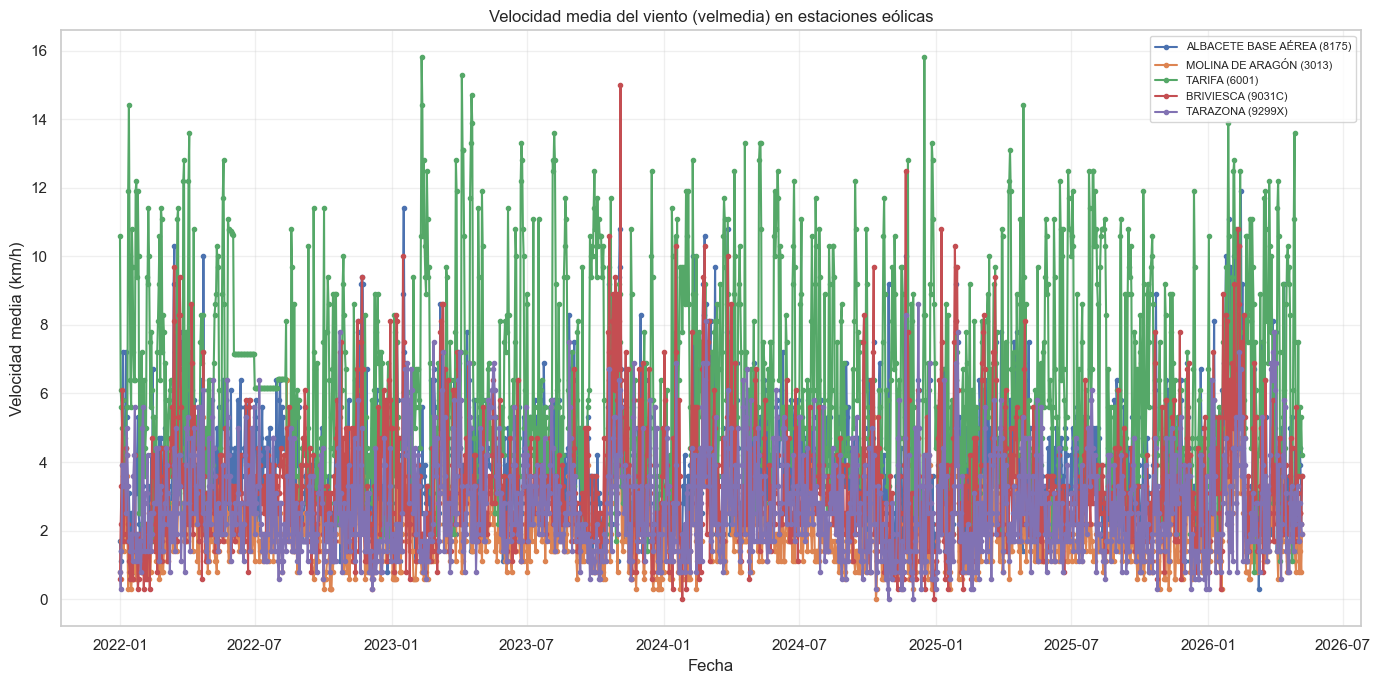

⚠️  Sin datos para estación 4584X


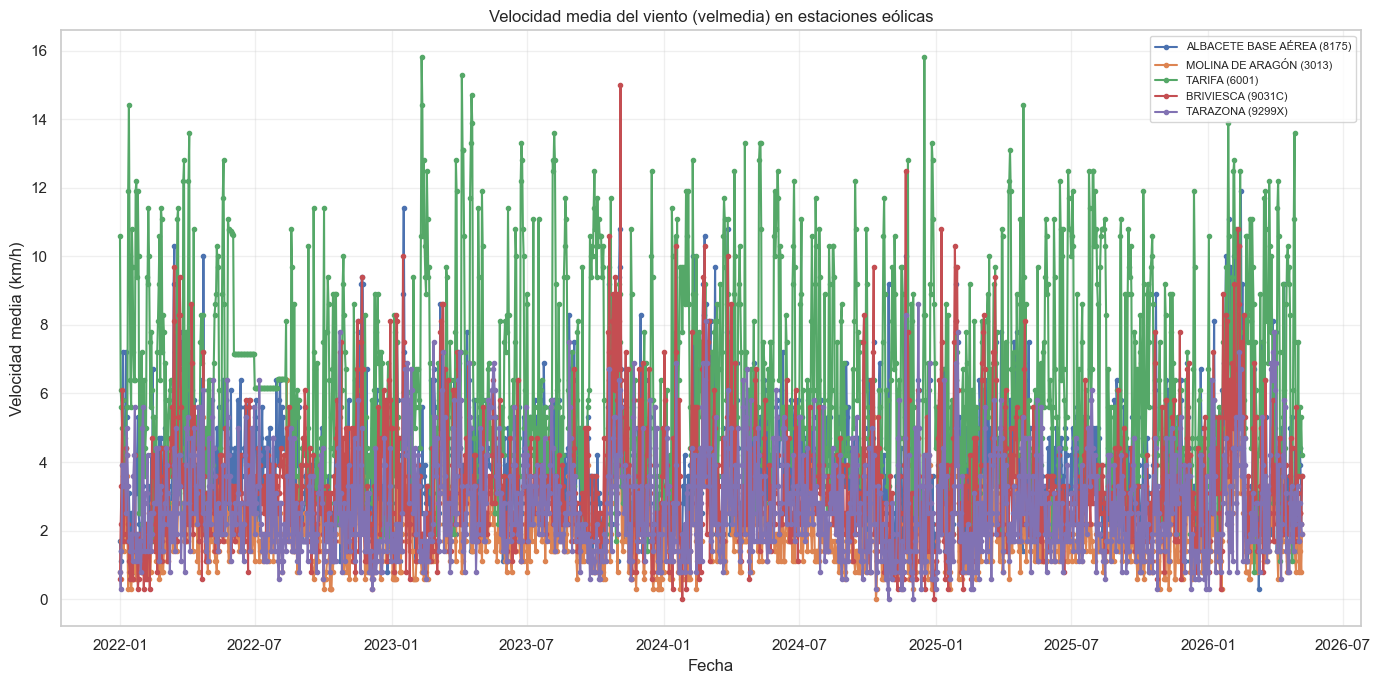

⚠️  Sin datos para estación 4584X


⚠️  Sin datos para estación 4584X


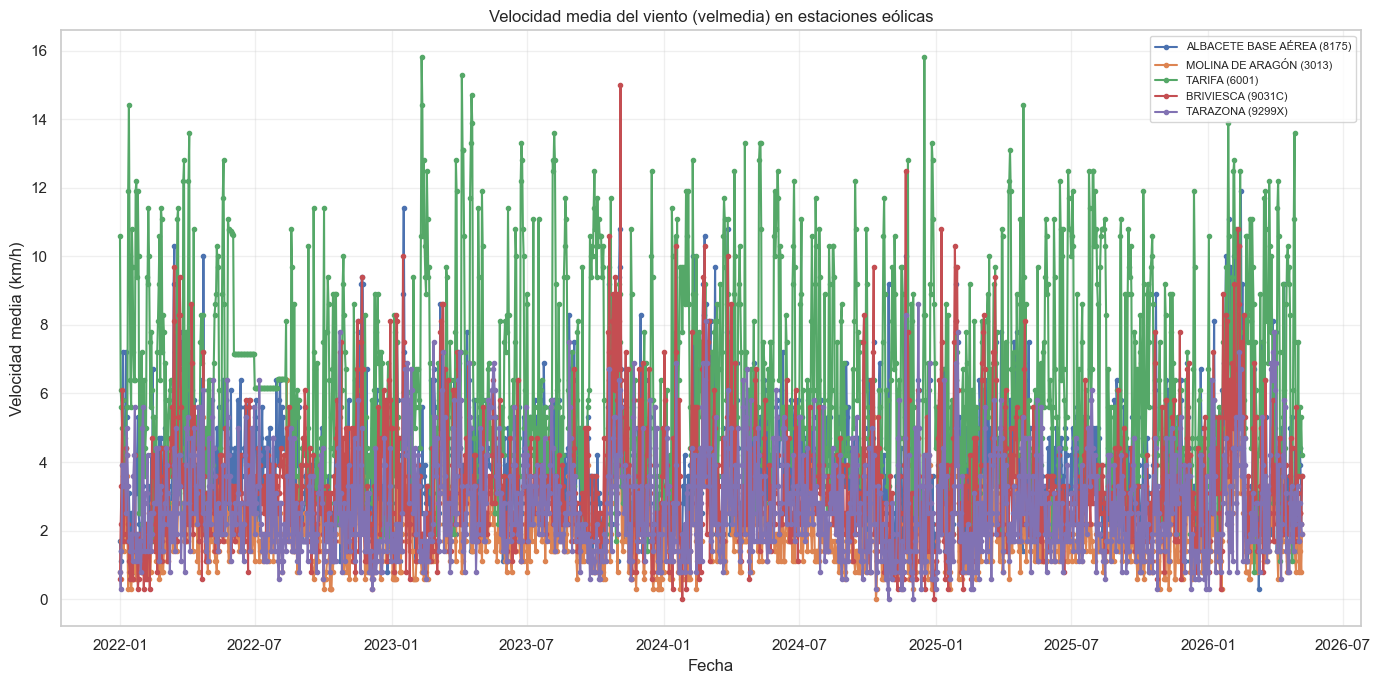

⚠️  Sin datos para estación 4584X


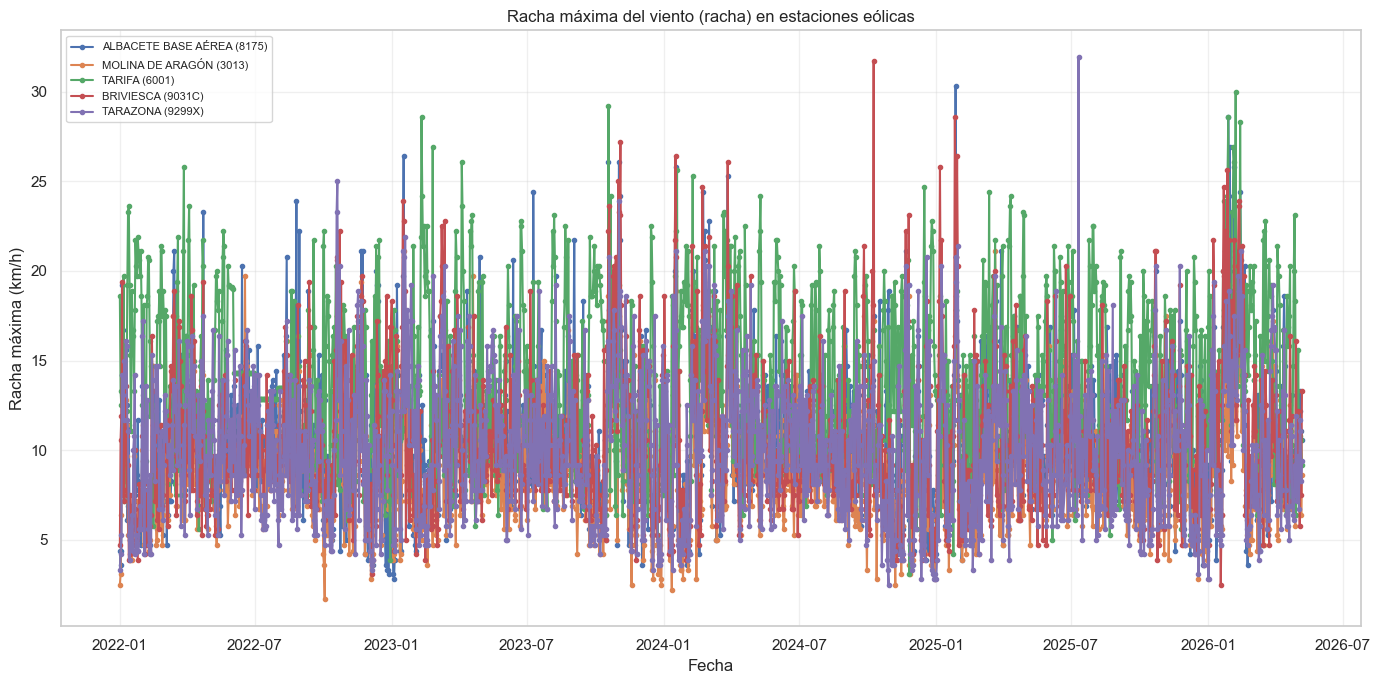

In [25]:
# Gráfica 1: Velocidad media del viento (velmedia) en estaciones eólicas
plt.figure(figsize=(14, 7))
for indicativo in ids_eolicas:
    df_est = df_meteorologica_eolica[df_meteorologica_eolica["indicativo"] == indicativo]
    if not df_est.empty:
        nombre = df_est["nombre"].iloc[0]
        plt.plot(df_est["fecha"], df_est["velmedia"], label=f"{nombre} ({indicativo})", marker="o", markersize=3)
    else:
        print(f"⚠️  Sin datos para estación {indicativo}")

plt.title("Velocidad media del viento (velmedia) en estaciones eólicas")
plt.xlabel("Fecha")
plt.ylabel("Velocidad media (km/h)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfica 2: Racha máxima del viento (racha) en estaciones eólicas
plt.figure(figsize=(14, 7))
for indicativo in ids_eolicas:
    df_est = df_meteorologica_eolica[df_meteorologica_eolica["indicativo"] == indicativo]
    if not df_est.empty:
        nombre = df_est["nombre"].iloc[0]
        plt.plot(df_est["fecha"], df_est["racha"], label=f"{nombre} ({indicativo})", marker="o", markersize=3)
    else:
        print(f"⚠️  Sin datos para estación {indicativo}")

plt.title("Racha máxima del viento (racha) en estaciones eólicas")
plt.xlabel("Fecha")
plt.ylabel("Racha máxima (km/h)")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


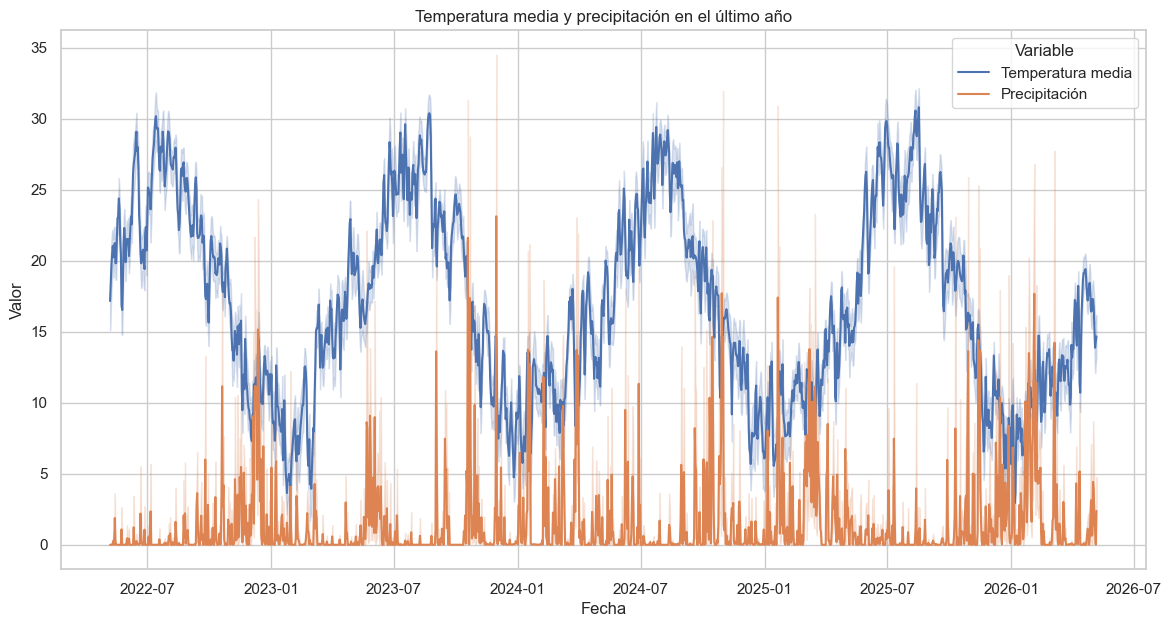

In [26]:
# ahora vamos a imprimir la gráfica del último año


In [27]:
import cdsapi
import xarray as xr
import pandas as pd
import time

def descargar_era5_sol_rapido(lat, lon, nombre, year_inicio, year_fin):
    c = cdsapi.Client()
    fichero_base = nombre.replace(' ', '_').replace('(','').replace(')','').replace('/','')
    
    dfs = []
    for year in range(year_inicio, year_fin + 1):
        fichero = f"era5_sol_{fichero_base}_{year}.nc"
        print(f"  {year}...", end=" ", flush=True)
        
        # Redondear al grid ERA5 más cercano (resolución 0.25°)
        lat_grid = round(lat * 4) / 4
        lon_grid = round(lon * 4) / 4
        
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": "surface_solar_radiation_downwards",
                "year":  str(year),
                "month": [f"{m:02d}" for m in range(1, 13)],
                "day":   [f"{d:02d}" for d in range(1, 32)],
                "time":  [f"{h:02d}:00" for h in range(24)],
                "area":  [lat_grid, lon_grid, lat_grid, lon_grid],  # un solo punto
                "data_format": "netcdf",
            },
            fichero
        )

        ds = xr.open_dataset(fichero)
        df = ds["ssrd"].to_dataframe().reset_index()
        df["fecha"] = pd.to_datetime(df["valid_time"]).dt.date.astype(str)
        df["sol_era5"] = df["ssrd"] / 3600
        df_dia = df.groupby("fecha")["sol_era5"].sum().reset_index()
        df_dia["fecha"] = pd.to_datetime(df_dia["fecha"])
        dfs.append(df_dia)
        print("✅")

    return pd.concat(dfs, ignore_index=True)

In [28]:
cdsapirc = os.path.join(os.path.expanduser("~"), ".cdsapirc")
copernicus_api_key = os.getenv('COPERNICUS_API_KEY')


with open(cdsapirc, "w") as f:
    f.write("url: https://cds.climate.copernicus.eu/api\n")
    f.write(f"key: {copernicus_api_key}\n")

print(f"✅ Fichero creado en {cdsapirc}")

✅ Fichero creado en C:\Users\jlalo\.cdsapirc


In [42]:
dfs_era5 = []
for parque in parques_fotovoltaicos:
    nombre = parque["nombre"]
    lat    = parque["latitud"]
    lon    = parque["longitud"]
    
    print(f"📡 {nombre}...", end=" ", flush=True)
    df = descargar_openmeteo_sol(lat, lon, nombre, fecha_inicio="2026-02-06", fecha_fin="2026-05-25")
    df["nombre"] = nombre
    dfs_era5.append(df)
    print(f"✅ {len(df)} días")

df_era5 = pd.concat(dfs_era5, ignore_index=True)
print(df_era5.head())

📡 Planta fotovoltaico Francisco Pizarro (Badajoz)... ✅ 109 días
📡 Fotovoltaica Núñez de Balboa (Badajoz)... ✅ 109 días
📡 Planta fotovoltaico Mula (Murcia)... ✅ 109 días
📡 Complejosolar  Don Rodrigo (Sevilla)... ✅ 109 días
📡 Chiprana-Samper (Zaragoza)... ✅ 109 días
       fecha  sol_pvgis                                           nombre
0 2026-02-06        NaN  Planta fotovoltaico Francisco Pizarro (Badajoz)
1 2026-02-07        NaN  Planta fotovoltaico Francisco Pizarro (Badajoz)
2 2026-02-08        NaN  Planta fotovoltaico Francisco Pizarro (Badajoz)
3 2026-02-09        NaN  Planta fotovoltaico Francisco Pizarro (Badajoz)
4 2026-02-10        NaN  Planta fotovoltaico Francisco Pizarro (Badajoz)


In [48]:
df_era5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fecha      545 non-null    datetime64[ns]
 1   sol_pvgis  405 non-null    float64       
 2   nombre     545 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 12.9+ KB
